In [1]:
import numpy as np
import matplotlib.pyplot as plt

An agent needs to have attributes:
- On/Off = 0 or 1
- neighbour list = list of surrounding neighbours
- probability of change = a function
- threshold of acceptance = float between 0 - 1

In [2]:
# profunc
def basic(neighbours):
    if not neighbours:
        return 0
    return sum(n.on for n in neighbours) / len(neighbours)


In [7]:
class Agent:
    def __init__(self, acc=0.5, profunction=basic):
        self.on = 0
        self.neighbours = []
        self.profunction = profunction
        self.acc = acc
        self.next = 0

    def set_func(self, func):
        self.profunction = func

    def compute_next(self):
        value = self.profunction(self.neighbours)
        self.next = 1 if value >= self.acc else 0

    def apply(self):
        self.on = self.next

    def update(self):
        self.compute_next()
        self.apply()

In [8]:
class Grid:
    def __init__(self, width, height, acc = 0.5, func = basic, init_probs = 0.2, seed = 100):
        self.width = width
        self.height = height
        rng = np.random.default_rng(seed)

        self.grid = [
            [Agent(acc=acc(x, y) if callable(acc) else acc, profunction=func)
             for x in range(width)]
            for y in range(height)
            ]

        for row in self.grid:
            for agent in row:
                agent.on = 1 if rng.random() < init_probs else 0
 
        self._wire_neighbours()


    def _wire_neighbours(self):
        for y in range(self.height):
            for x in range(self.width):
                agent = self.grid[y][x]
                neighbours = []
                for dx, dy in [(-1, 0), (1, 0), (0, -1), (0, 1)]:
                    nx, ny = x + dx, y + dy
                    nx %= self.width
                    ny %= self.height
                    neighbours.append(self.grid[ny][nx])
                agent.neighbours = neighbours

    def step(self):
        for row in self.grid:
            for agent in row:
                agent.compute_next()
        for row in self.grid:
            for agent in row:
                agent.apply()

    def state_array(self):
        return np.array([[agent.on for agent in row] for row in self.grid])

    def fraction_on(self):
        arr = self.state_array()
        return arr.mean()

In [37]:
def plot_grid(grid, ax=None, title=None):
    """
    Plot the current state of the grid.
    """
    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 6))

    ax.imshow(
        grid.state_array(),
        cmap="binary",
        vmin=0,
        vmax=1,
        interpolation="nearest"
    )

    ax.set_xlabel("x")
    ax.set_ylabel("y")

    if title:
        ax.set_title(title)

    return ax


def run_simulation(grid, steps=20, visualise=True):
    """
    Run the simulation and record the fraction of agents ON.
    """
    fractions = [grid.fraction_on()]

    if visualise:
        fig, axes = plt.subplots(1, 2, figsize=(12, 5))

        # Initial grid
        axes[0].imshow(
            grid.state_array(),
            cmap="binary",
            vmin=0,
            vmax=1,
            interpolation="nearest"
        )

        axes[0].set_title("Initial state")
        axes[0].set_xlabel("x")
        axes[0].set_ylabel("y")

        # Run simulation
        for _ in range(steps):
            grid.step()
            fractions.append(grid.fraction_on())

        # Final grid
        axes[1].imshow(
            grid.state_array(),
            cmap="binary",
            vmin=0,
            vmax=1,
            interpolation="nearest"
        )

        axes[1].set_title(f"Final state (t={steps})")
        axes[1].set_xlabel("x")
        axes[1].set_ylabel("y")

        plt.tight_layout()
        plt.show()

        # Plot fraction ON
        '''
        plt.figure(figsize=(8, 4))
        plt.plot(
            range(steps + 1),
            fractions,
            marker="o"
        )

        plt.xlabel("Time step")
        plt.ylabel("Fraction ON")
        plt.title("Fraction of agents that are ON")
        plt.ylim(0, 1)
        plt.grid(True, alpha=0.3)
        plt.show()

        '''

    return fractions


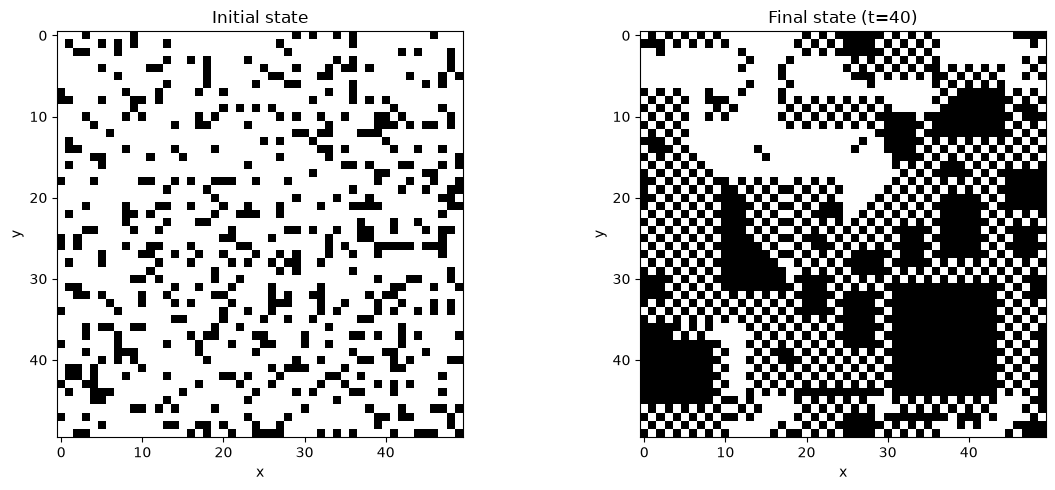

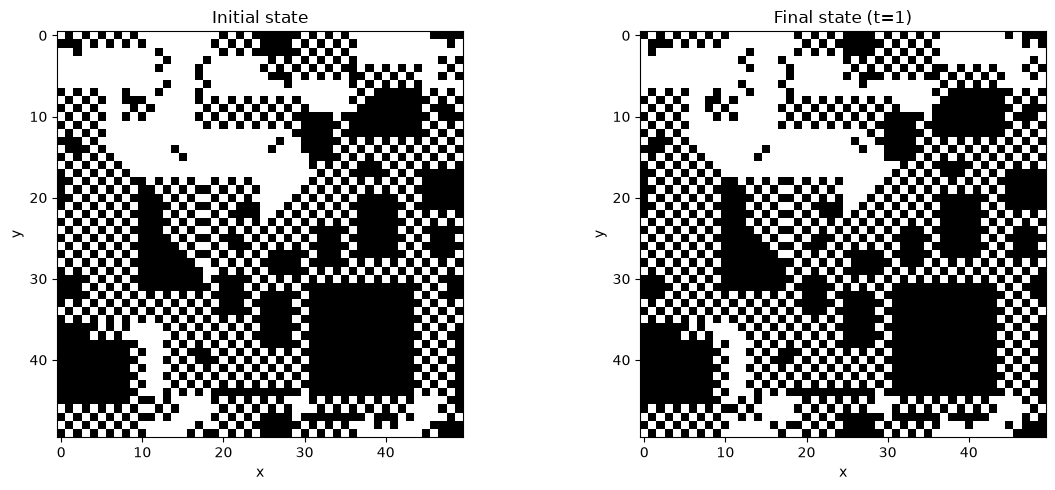

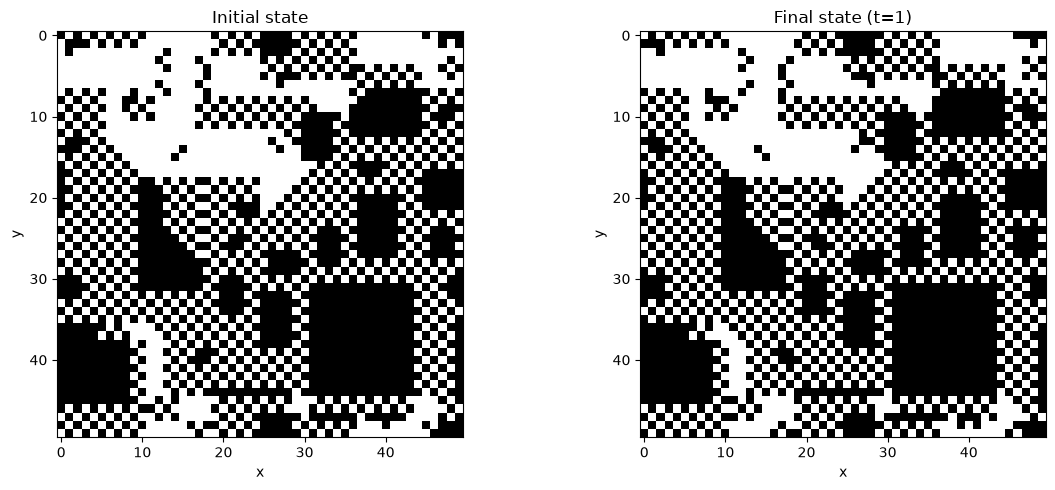

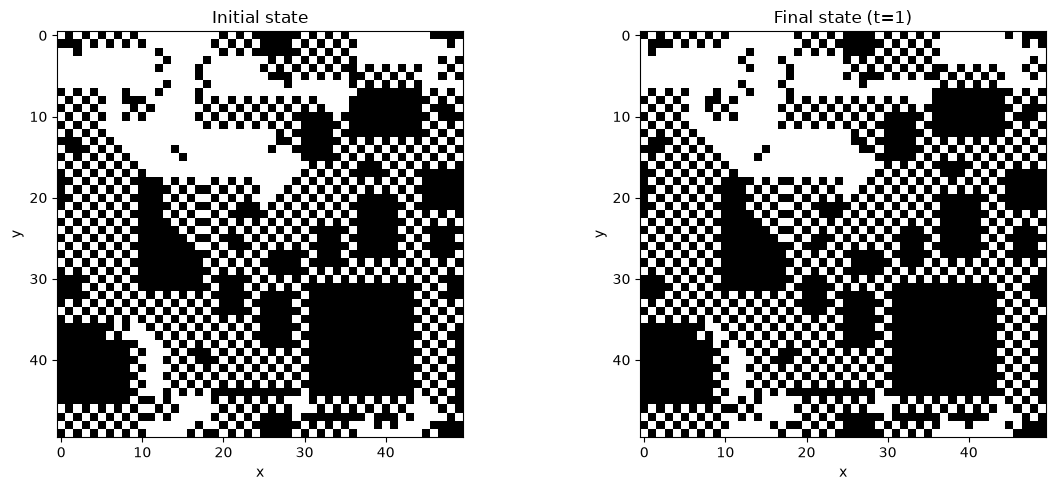

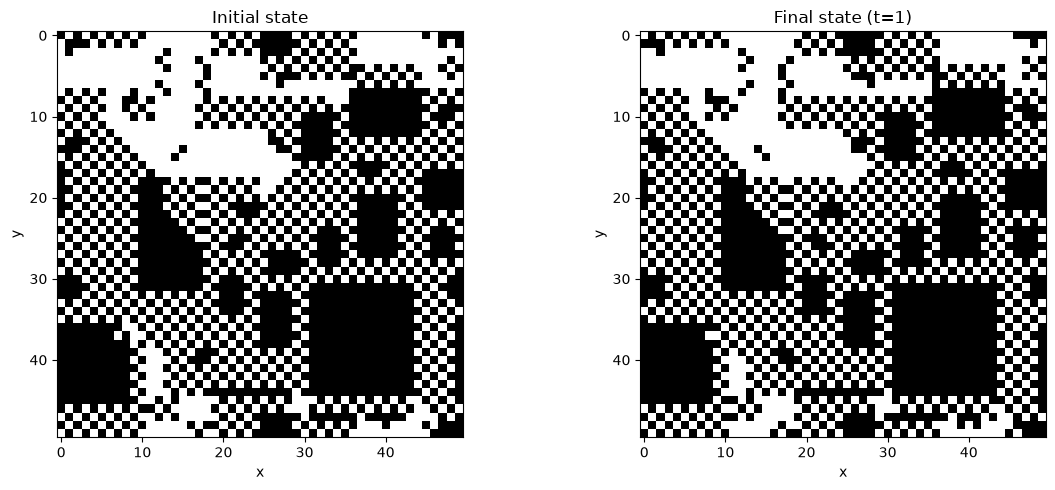

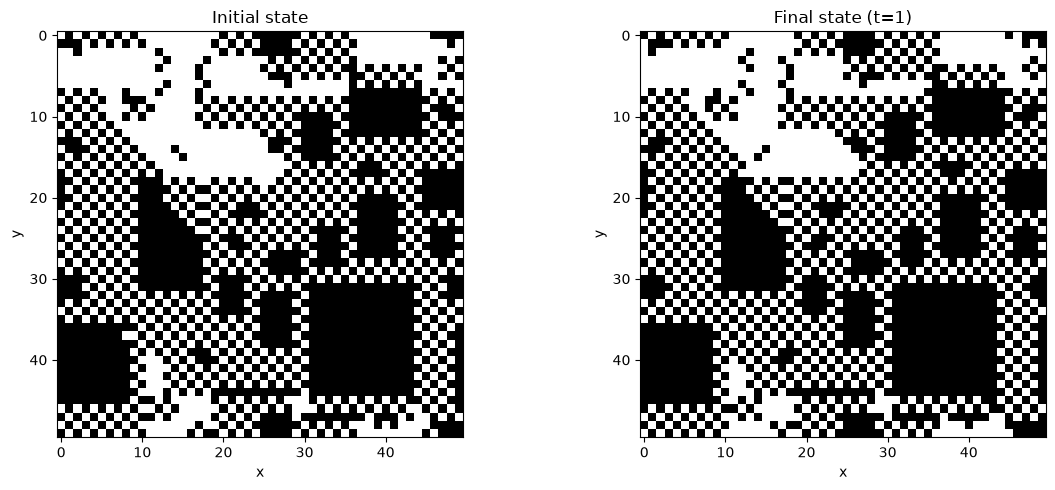

In [43]:
grid = Grid(
    width=50,
    height=50,
    acc=0.5,
    func=basic,
    init_probs=0.2,
    seed=100
)

fractions = run_simulation(
    grid,
    steps=40
)

fractions = run_simulation(
    grid,
    steps=1
)

fractions = run_simulation(
    grid,
    steps=1
)

fractions = run_simulation(
    grid,
    steps=1
)

fractions = run_simulation(
    grid,
    steps=1
)

fractions = run_simulation(
    grid,
    steps=1
)

In [ ]:
# try more neighbours, see if the pattern disappears, moore neighbourhood
# update now random, probability
# introduce cost
